<a href="https://colab.research.google.com/github/kuroshkarimi/Machine-Learning-and-Data-Analysis/blob/main/Deep_Learning/Classification_Threshold_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



Create a dataset with 20-000 total sample; out of these samples, 2% should be positive and the rest negative. Then train a small neural network, inspect its scores, select a threshold using validation data, and report the untouched test result.

For generation of the data use 'make_classification()' function from sickit learn data package with the following characteristics:

| Parameter | Definition|
|---|---|
| `n_samples=20_000` | Generate 20,000 observations. The underscore makes the number easier to read; `20_000` equals `20000`. |
| `n_features=20` | Give each observation 20 numerical features. |
| `n_informative=10` | Use 10 original features to construct patterns that distinguish the classes. |
| `n_redundant=5` | Add 5 features created as random linear combinations of the informative features. |
| `weights=[0.98, 0.02]` | Assign 98% of samples to class `0` and 2% to class `1`. |
| `flip_y=0` | Disable random reassignment of class labels. |
| `random_state=42` | Fix the random seed so the same call is reproducible in the same software environment. |


Use a minimum recall requirement of 80% and, among thresholds meeting it, chooses the one with the highest validation precision. That is an illustrative policy; in a real project, the required recall should come from the consequences and capacity of the application.

In [ ]:
# Importing required libraries
from sklearn.datasets import make_classification
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Input, Activation, Dropout, BatchNormalization
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    average_precision_score,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,

    )

from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

In [ ]:
# Fix the random seeds

SEED = 42
tf.keras.utils.set_random_seed(SEED)

In [ ]:
# Creating the data as required

n_feature = 20
x, y = make_classification(
    n_samples = 20_000,
    n_features = n_feature,
    n_informative = 10,
    n_redundant = 5,
    weights = [0.98, 0.02],
    flip_y = 0,
    random_state = SEED
)

print(y)

[0 0 0 ... 0 0 0]


In [ ]:
# Splitting the data into training, validation and test sets

x_tr_val, x_test, y_tr_val, y_test = train_test_split(
                        x, y, test_size = 0.2,
                        stratify = y, random_state = SEED)


x_train, x_val, y_train, y_val = train_test_split(
                        x_tr_val, y_tr_val, test_size = 0.25,
                        stratify = y_tr_val, random_state = SEED)

In [ ]:
# Now we see if the population of the positives is 2% across all parts

print(np.mean(y_train), np.mean(y_val), np.mean(y_test))

0.02 0.02 0.02


In [ ]:
# Scaling the data through the scaling parameters attained from the training set

scaler = StandardScaler()
scaler.fit_transform(x_train)
x_train = scaler.transform(x_train)
x_val = scaler.transform(x_val)
x_test = scaler.transform(x_test)

In [ ]:
# Creating the architecture of the model

model = Sequential([
    Input(shape = (n_feature,)),

    Dense(100, activation = 'relu', kernel_initializer = 'he_normal'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(50, activation = 'relu', kernel_initializer = 'he_normal'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(25, activation = 'relu', kernel_initializer = 'he_normal'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(1, activation = 'sigmoid')

]
)



In [ ]:
# Compiling the model

model.compile(
    optimizer = Adam(learning_rate = 0.0001),
    loss = 'binary_crossentropy'
)


In [ ]:

# Early stopping criteria
early_stopping = EarlyStopping(
    monitor = 'val_loss',
    patience = 10,
    restore_best_weights = True,
    verbose = 1,
    mode = 'min',
    min_delta = 0,

    )


# Model to be saved
model_checkpoint = ModelCheckpoint(
    'model.keras',
    monitor = 'val_loss',
    mode = 'min',
    save_best_only = True,
    verbose = 1
)


# Adjusting the learning rate
lr_reduce = ReduceLROnPlateau(
    monitor = 'val_loss',
    factor = 0.1,
    patience = 5,
    verbose = 1,
    mode = 'min',
    min_delta = 0
)





In [ ]:
# Fitting the model

HIST = model.fit(x_train, y_train,
          validation_data = (x_val, y_val),
          epochs = 200,
          callbacks = [early_stopping, model_checkpoint, lr_reduce],
          verbose = 1,
          batch_size = 200,
          shuffle = True,

)

Epoch 1/200
57/60 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.9050
Epoch 1: val_loss improved from None to 0.95931, saving model to model.keras

Epoch 1: finished saving model to model.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.8854 - val_loss: 0.9593 - learning_rate: 1.0000e-04
Epoch 2/200
50/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.8505
Epoch 2: val_loss improved from 0.95931 to 0.70038, saving model to model.keras

Epoch 2: finished saving model to model.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.8363 - val_loss: 0.7004 - learning_rate: 1.0000e-04
Epoch 3/200
58/60 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.8140
Epoch 3: val_loss improved from 0.70038 to 0.61159, saving model to model.keras

Epoch 3: finished saving model to model.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.8011 - val_loss: 0.6116 - learning_rate: 1.0000e-04
Epoch 4/200
58/60 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.7761
Epoch 4: val_loss improved from 0.61159 to 0.57076

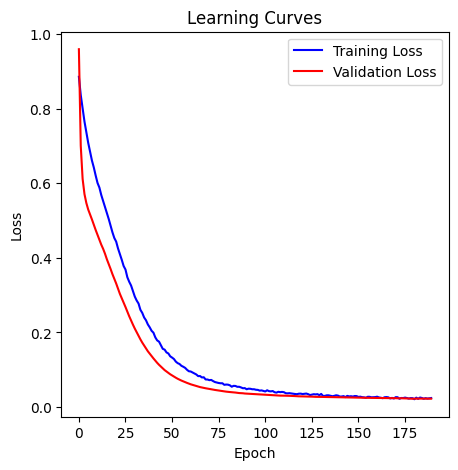

In [ ]:
# plotting the learning curves

plt.figure(figsize = (5, 5))
plt.plot(HIST.history['loss'], label = 'Training Loss', color = 'blue')
plt.plot(HIST.history['val_loss'], label = 'Validation Loss', color = 'red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Learning Curves')
plt.legend()
plt.show()

In [ ]:
val_scores = model.predict(x_val).ravel()


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
print('validation average precision:',
      average_precision_score(y_val, val_scores))


validation average precision: 0.907389796654652


The average precision score above is a measure of how the model ranks the positive class over negative class. considering a perfect model has the average precision equals to 1, the closer the resulting value to it, the better.

Now, considering the minimum recall requirement of 80%, we should see which value of the threshold gives the highest value of precision. To do this, we define a function to evaluate the vlaues of recall and precision in presence of a given threshold. Then iterate over it to get the intended response.

In [ ]:
predicted_label = (val_scores >= 0.6).astype(int)
predicted_label

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
def report_at_threshold(true_label, predicted_probability, threshold):
  predicted_label = (predicted_probability >= threshold).astype(int)
  precision = precision_score(true_label, predicted_label, zero_division=0)
  recall = recall_score(true_label, predicted_label, zero_division=0)

  return round(float(threshold), 2), round(precision, 2), round(recall, 2)

for idx, thresh in enumerate(np.arange(0, 1, 0.05)):
  print(idx, report_at_threshold(y_val, val_scores, thresh))

0 (0.0, 0.02, 1.0)
1 (0.05, 0.77, 0.85)
2 (0.1, 0.86, 0.82)
3 (0.15, 0.9, 0.76)
4 (0.2, 0.92, 0.76)
5 (0.25, 0.94, 0.74)
6 (0.3, 0.97, 0.72)
7 (0.35, 0.98, 0.72)
8 (0.4, 0.98, 0.7)
9 (0.45, 0.98, 0.7)
10 (0.5, 1.0, 0.69)
11 (0.55, 1.0, 0.68)
12 (0.6, 1.0, 0.65)
13 (0.65, 1.0, 0.61)
14 (0.7, 1.0, 0.6)
15 (0.75, 1.0, 0.59)
16 (0.8, 1.0, 0.57)
17 (0.85, 1.0, 0.54)
18 (0.9, 1.0, 0.53)
19 (0.95, 1.0, 0.47)


In [ ]:
precision, recall, threshold = precision_recall_curve(y_val, val_scores)
print(precision.shape, recall.shape, threshold.shape)

(3995,) (3995,) (3994,)


In [ ]:
result = pd.DataFrame({
    'precision': precision[:-1],
    'recall': recall[:-1],
    'threshold': threshold
})


In [ ]:
refined = result.loc[result.recall > 0.8, :]
max_precision = refined.loc[refined.precision.idxmax(), :]
max_precision

,3925
precision,0.866667
recall,0.812500
threshold,0.107901


In [ ]:
max_precision


,3925
precision,0.866667
recall,0.812500
threshold,0.107901


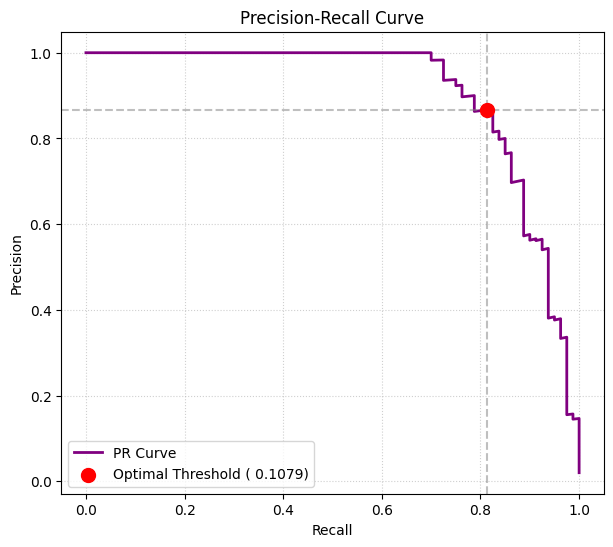

In [ ]:
plt.figure(figsize=(7, 6))
plt.plot(recall, precision, label='PR Curve', color='purple', lw=2)

# Highlight our chosen optimal threshold point
plt.scatter(max_precision.iloc[1], max_precision.iloc[0], color='red', s=100, zorder=5,
            label=f"Optimal Threshold ({max_precision.iloc[2]: .4f})")

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.axhline(y=max_precision.iloc[0], color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=max_precision.iloc[1], color='gray', linestyle='--', alpha=0.5)
plt.legend(loc='lower left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

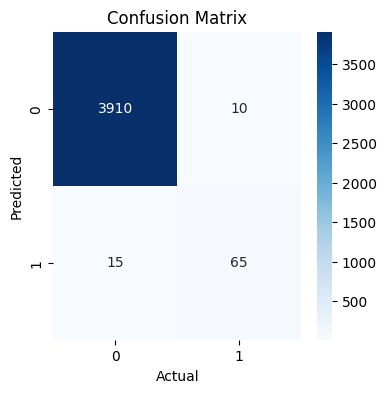

In [ ]:
import seaborn as sns
cm = confusion_matrix(y_val,
           (val_scores >= max_precision['threshold']).astype(int))

plt.figure(figsize = (4, 4))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

In [ ]:

# Make predictions on the untouched test set
test_scores = model.predict(x_test).ravel()
test_preds = (test_scores >= max_precision['threshold']).astype(int)

# Generate and display the final classification report on the test set
print(f"--- Final Evaluation on Untouched Test Set (Threshold: {max_precision['threshold']:.4f}) ---")
print(classification_report(y_test, test_preds))

# Display the final confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, test_preds))

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
--- Final Evaluation on Untouched Test Set (Threshold: 0.1079) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3920
           1       0.87      0.90      0.88        80

    accuracy                           1.00      4000
   macro avg       0.93      0.95      0.94      4000
weighted avg       1.00      1.00      1.00      4000

Confusion Matrix:
[[3909   11]
 [   8   72]]
